In [1]:
import numpy as np
from besta import Reader
import pandas as pd
import matplotlib.pyplot as plt
from besta.postprocess import summarize_results
import scienceplots

plt.style.use('science')

In [2]:
nspec_folder = 'nspec'

In [3]:
#df = pd.read_csv('sheets/2D_Gauss_dist_timesc.csv')
df = pd.read_csv('./sheets/2D_Gauss_dist_timesc.csv')
df = df[df['SNR_RED'] >= 3]

exclude_nspecs = [6, 8, 17, 29, 35, 37, 59, 64]
df = df[~df['nspec'].isin(exclude_nspecs)]

title_size = 16
ax_size = 15
suptitle_size = 18
c_size = 11
legend_size = 11

# Define Plotting Functions

In [4]:
def weighted_percentile(data, weights):
    data = np.array(data)
    weights = np.array(weights)
    
    sorter = np.argsort(data)
    data = data[sorter]
    weights = weights[sorter]

    total = np.sum(weights)

    if total == 0:
        return np.nan, np.nan, np.nan
    
    cdf = np.cumsum(weights) / total
    p16 = np.interp(0.16, cdf, data)
    p50 = np.interp(0.50, cdf, data)
    p84 = np.interp(0.84, cdf, data)
    return p16, p50, p84

def weighted_std(values, weights):
    """Weighted standard deviation from posterior samples."""
    wmean = np.sum(weights * values) / np.sum(weights)
    variance = np.sum(weights * (values - wmean)**2) / np.sum(weights)
    return np.sqrt(variance)

def extract_post(nspec):
        
    reader = Reader.from_results_file(f"./output/{nspec_folder}/{nspec}/fit_all.txt")
    reader.load_results()
    table = reader.results_table
    
    t90s = table['stars.sfh--t_at_frac_0.9000'].data
    t99s = table['stars.sfh--t_at_frac_0.9900'].data
    m = table['extra--stellar_mass'].data
    post = table['post'].data
    
    log_w = post - post.max()
    w = np.exp(log_w)
    w = w / w.sum()

    return t99s, t90s, m, log_w, w

#for i, nspec in enumerate(nspecs_A2142):
#    t99s, t90s, log_w, w = extract_post(nspec)
#    delta_t = t99s - t90s
#    print(delta_t[1]-delta_t[0], delta_t[2]-delta_t[1], delta_t[3]-delta_t[2],)
#    print(f"Max: {delta_t.max()}, Min: {delta_t.min()}")

def get_pdfs(nspec, edges):
    t99s, t90s, m, log_w, w = extract_post(nspec)
    delta_t = t99s - t90s

    pdf_dt,  _ = np.histogram(delta_t, bins=edges, weights=w, density=False)
    pdf_t99, _ = np.histogram(t99s,    bins=edges, weights=w, density=False)
    pdf_m, _   = np.histogram(m,       bins=edges, weights=w, density=False)

    if pdf_dt.sum()  > 0: pdf_dt  = pdf_dt  / pdf_dt.sum()
    if pdf_t99.sum() > 0: pdf_t99 = pdf_t99 / pdf_t99.sum()

    # --- Compute weighted std directly from posterior samples ---
    std_dt  = weighted_std(delta_t, w)
    std_t99 = weighted_std(t99s,    w)
    std_m   = weighted_std(m,       w)

    return pdf_dt, pdf_t99, pdf_m, std_dt, std_t99, std_m
    
    
def sum_bin_post(bin_edges, coord='D_fil', df=df, pdf_plot=False):
    # --- Define a common Δt grid ---
    # Inspect range across all galaxies first; adjust lo/hi/n_bins as needed
    lim_lo, lim_hi = 0, 15.0   # Gyr — adjust to your data range
    n_bins = 500                           # resolution of the PDF grid
    edges = np.linspace(lim_lo, lim_hi, n_bins + 1)
    mids  = 0.5 * (edges[:-1] + edges[1:])


    # --- Bin galaxies spatially ---
    df['bin'] = pd.cut(df[coord], bins=bin_edges)
    grouped = list(df.groupby('bin', observed=True))
    n_spatial_bins = len(grouped)

    figsize_per_panel = (4, 3)
    ncols = 3
    # --- Set up the grid of subplots once, before the loop ---
    if pdf_plot:
        nrows = int(np.ceil(n_spatial_bins / ncols))
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
            squeeze=False
        )
        axes_flat = axes.flatten()

    bin_results = []
    for i, (bin_interval, bin_group) in enumerate(grouped):
        nspec_list = bin_group['nspec'].tolist()
        n_gal = len(nspec_list)

        # --- Get one normalized PDF per galaxy ---
        pdfs_dt  = []
        pdfs_t99 = []
        pdfs_m   = []
        stds_dt  = []
        stds_t99 = []
        stds_m   = []
        for nspec in nspec_list:
            pdf_dt, pdf_t99, pdf_m, std_dt, std_t99, std_m = get_pdfs(nspec, edges)
            pdfs_dt.append(pdf_dt)
            pdfs_t99.append(pdf_t99)
            pdfs_m.append(pdf_m)
            stds_dt.append(std_dt)
            stds_t99.append(std_t99)
            stds_m.append(std_m)
        
        stds_dt  = np.array(stds_dt)
        stds_t99 = np.array(stds_t99)

        # --- Composite PDFs -> Stack and sum (each row = one galaxy's PDF)---
        composite_dt  = np.sum(np.vstack(pdfs_dt),  axis=0)
        composite_t99 = np.sum(np.vstack(pdfs_t99), axis=0)
        composite_m = np.sum(np.vstack(pdfs_m), axis=0)

        # --- Per-galaxy medians and widths ---
        percs_dt  = [weighted_percentile(mids, pdf) for pdf in pdfs_dt]
        percs_t99 = [weighted_percentile(mids, pdf) for pdf in pdfs_t99]

        gal_p16_dt  = np.array([p[0] for p in percs_dt])
        gal_p50_dt  = np.array([p[1] for p in percs_dt])
        gal_p84_dt  = np.array([p[2] for p in percs_dt])

        gal_p16_t99 = np.array([p[0] for p in percs_t99])
        gal_p50_t99 = np.array([p[1] for p in percs_t99])
        gal_p84_t99 = np.array([p[2] for p in percs_t99])

        
        # --- Inverse-variance weighted mean and error ---
        weights_dt  = 1 / stds_dt**2
        weights_t99 = 1 / stds_t99**2

        total_dt  = weights_dt.sum()
        total_t99 = weights_t99.sum()

        wmean_dt  = np.sum(weights_dt  * gal_p50_dt)  / total_dt
        wmean_t99 = np.sum(weights_t99 * gal_p50_t99) / total_t99

        werr_dt  = np.sqrt(1 / total_dt)
        werr_t99 = np.sqrt(1 / total_t99)
        
        # --- Composite PDF Percentiles ---
        p16,     p50,     p84     = weighted_percentile(mids, composite_dt)
        p16_t99, p50_t99, p84_t99 = weighted_percentile(mids, composite_t99)
        p16_m, p50_m, p84_m       = weighted_percentile(mids, composite_m)

        # -- PDF Plot: draw into this bin's axis in the shared grid --
        if pdf_plot:
            
            ax = axes_flat[i]
            for pdf in pdfs_dt:
                ax.plot(mids, pdf, color='orange', alpha=0.3, linewidth=0.8)
            ax.plot(mids, composite_dt / composite_dt.sum(), color='cornflowerblue',
                     linewidth=1, label='Composite PDF')
            ax.axvline(p50,      color='magenta', linestyle='--', label=f'median = {p50:.2f} Gyr')
            ax.axvline(p16,      color='k',       linestyle=':',  label=f'p16 = {p16:.2f} Gyr', linewidth=0.8)
            ax.axvline(p84,      color='k',       linestyle=':',  label=f'p84 = {p84:.2f} Gyr', linewidth=0.8)
            ax.axvline(wmean_dt, color='teal',    linestyle='--', label=f'wmean = {wmean_dt:.2f} Gyr', linewidth=0.8)
            ax.set_xlabel(r'$\Delta t$ [Gyr]')
            ax.set_ylabel('PDF')
            ax.set_title(f'Bin {bin_interval} (N={n_gal})', fontsize=9)
            ax.legend(fontsize=6)

        bin_results.append({
            coord + '_bin':  bin_interval,
            coord + '_mid':  bin_interval.mid,
            'N_gal':         n_gal,
            'timesc':        p50,
            'err_lo':        p50 - p16,
            'err_hi':        p84 - p50,
            't99':           p50_t99,
            'err_lo_t99':    p50_t99 - p16_t99,
            'err_hi_t99':    p84_t99 - p50_t99,
            'wmean_timesc':  wmean_dt,
            'werr_timesc':   werr_dt,
            'wmean_t99':     wmean_t99,
            'werr_t99':      werr_t99,
            'mass':          p50_m,
            'err_lo_m':      p50_m - p16_m,
            'err_hi_m':      p84_m - p50_m,
        })

    # --- Finalise figure after the loop ---
    if pdf_plot:
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        fig.tight_layout(pad=1)
        fig.savefig(f'./output/{nspec_folder}/plots/binned/cdf_plots.pdf', bbox_inches='tight')
        plt.show()

    return pd.DataFrame(bin_results)

In [5]:
def plot_old_recent(bin_old_df, bin_recent_df, bin_edges, coord='D_fil', save_path=None, suptitle=None):

    if coord in ('D_fil', 'D_fil_2D'):
        xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_fil_2D':
            xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc]'
    elif coord in ('D_along', 'D_along_2D'):
        xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_along_2D':
            xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc]'

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths  = np.diff(bin_edges)

    fig = plt.figure(figsize=(16, 7))
    gs  = fig.add_gridspec(2, 2, height_ratios=[6, 1], hspace=0.05, wspace=0.12)

    ax0   = fig.add_subplot(gs[0, 0])
    ax0_n = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax1   = fig.add_subplot(gs[0, 1])
    ax1_n = fig.add_subplot(gs[1, 1], sharex=ax1)

    # ── Star-forming (left column) ───────────────────────────────────────────
    ax0.errorbar(df[coord][mask_recent], df['timesc'][mask_recent],
                 yerr=[df['err_lo'][mask_recent], df['err_hi'][mask_recent]],
                 fmt='o', color='royalblue', alpha=0.3, markersize=4,
                 elinewidth=0.8, capsize=2, label='Individual galaxies')
    ax0.errorbar(bin_recent_df[f'{coord}_mid'], bin_recent_df['timesc'],
                 yerr=[bin_recent_df['err_lo'], bin_recent_df['err_hi']],
                 fmt='D', color='midnightblue', markersize=8,
                 elinewidth=2, capsize=4, label='Binned median')
    for edge in bin_edges:
        ax0.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax0.set_title(r'$t_{obs}-\tau_{99} < 1$ Gyr (Star-forming)', fontsize=title_size)
    ax0.set_ylabel(r'$\tau_{99} - \tau_{90}$ [Gyr]', fontsize=ax_size)
    ax0.tick_params(labelbottom=False)
    ax0.legend(fontsize=legend_size)

    # Count bar (star-forming)
    counts_recent, _ = np.histogram(df[coord][mask_recent].dropna(), bins=bin_edges)
    ax0_n.bar(bin_centers, counts_recent, width=bin_widths * 0.85,
              color='royalblue', alpha=0.5, linewidth=0.6, edgecolor='white')
    for cx, cnt in zip(bin_centers, counts_recent):
        if cnt > 0:
            ax0_n.text(cx, cnt / 2, str(cnt),
                       ha='center', va='center', fontsize=c_size,
                       fontweight='bold', color='midnightblue')
    for edge in bin_edges:
        ax0_n.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax0_n.set_xlabel(xlabel, fontsize=ax_size)
    ax0_n.set_ylabel('N', fontsize=ax_size)
    ax0_n.set_yticks([])
    ax0_n.tick_params(axis='both', which='both', length=0)
    ax0_n.spines[['top', 'right', 'left']].set_visible(False)

    # ── Quiescent (right column) ─────────────────────────────────────────────
    ax1.errorbar(df[coord][mask_old], df['timesc'][mask_old],
                 yerr=[df['err_lo'][mask_old], df['err_hi'][mask_old]],
                 fmt='o', color='red', alpha=0.3, markersize=4,
                 elinewidth=0.8, capsize=2, label='Individual galaxies')
    ax1.errorbar(bin_old_df[f'{coord}_mid'], bin_old_df['timesc'],
                 yerr=[bin_old_df['err_lo'], bin_old_df['err_hi']],
                 fmt='D', color='crimson', markersize=8,
                 elinewidth=2, capsize=4, label='Binned median')
    for edge in bin_edges:
        ax1.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax1.set_title(r'$t_{obs}-\tau_{99} \geq 1$ Gyr (Quiescent)', fontsize=title_size)
    ax1.set_ylabel(r'$\tau_{99} - \tau_{90}$ [Gyr]', fontsize=ax_size)
    ax1.tick_params(labelbottom=False)
    ax1.legend(fontsize=legend_size)

    # Count bar (quiescent)
    counts_old, _ = np.histogram(df[coord][mask_old].dropna(), bins=bin_edges)
    ax1_n.bar(bin_centers, counts_old, width=bin_widths * 0.85,
              color='red', alpha=0.5, linewidth=0.6, edgecolor='white')
    for cx, cnt in zip(bin_centers, counts_old):
        if cnt > 0:
            ax1_n.text(cx, cnt / 2, str(cnt),
                       ha='center', va='center', fontsize=c_size,
                       fontweight='bold', color='crimson')
    for edge in bin_edges:
        ax1_n.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax1_n.set_xlabel(xlabel, fontsize=ax_size)
    ax1_n.set_ylabel('N', fontsize=ax_size)
    ax1_n.set_yticks([])
    ax1_n.tick_params(axis='both', which='both', length=0)
    ax1_n.spines[['top', 'right', 'left']].set_visible(False)

    fig.suptitle(suptitle, fontsize=suptitle_size)
    fig.subplots_adjust(top=0.88)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()
    plt.close(fig)

In [6]:
def plot_timesc(bin_df, bin_edges, coord='D_fil', mean=False, savepath=None, title=None):
    if coord in ('D_fil', 'D_fil_2D'):
        c1, c2 = 'steelblue', 'crimson'
        xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_fil_2D':
            xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc]'
    elif coord in ('D_along', 'D_along_2D'):
        xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc] (3D)'
        c1, c2 = 'royalblue', 'mediumvioletred'
        if coord == 'D_along_2D':
            xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc]'

    if mean:
        y = bin_df['wmean_timesc']
        yerr = bin_df['werr_timesc']
        label = 'Binned weighted mean'
    else:
        y = bin_df['timesc']
        yerr = [bin_df['err_lo'], bin_df['err_hi']]
        label = 'Binned median'

    # --- Layout: main panel + slim count bar ---
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[6, 1], hspace=0.05)
    ax = fig.add_subplot(gs[0])
    ax_n = fig.add_subplot(gs[1], sharex=ax)

    # --- Main panel ---
    ax.errorbar(df[coord], df['timesc'],
                yerr=[df['err_lo'], df['err_hi']],
                fmt='o', color=c1, alpha=0.3, markersize=4,
                elinewidth=0.8, capsize=2, label='Individual galaxies')
    ax.errorbar(bin_df[coord + '_mid'], y, yerr=yerr,
                fmt='D', color=c2, markersize=8,
                elinewidth=2, capsize=4, label=label)
    for edge in bin_edges:
        ax.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_ylabel(r'$\tau_{99} - \tau_{90}$ [Gyr]', fontsize=ax_size)
    ax.set_title(title, fontsize=title_size)
    if coord in ('D_along', 'D_along_2D'):
        ax.axvline(0, color='crimson', lw=1.2, ls='--', label='A2142 centre')
    ax.legend(fontsize=legend_size)
    ax.tick_params(labelbottom=False)  # hide x-tick labels on main panel

    # --- Count bar ---
    counts, _ = np.histogram(df[coord].dropna(), bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths  = np.diff(bin_edges)

    ax_n.bar(bin_centers, counts, width=bin_widths * 0.85,
             color=c1, alpha=0.5, linewidth=0.6, edgecolor='white')

    # Label each bar with its count
    for cx, cnt in zip(bin_centers, counts):
        ax_n.text(cx, cnt / 2, str(cnt),
                  ha='center', va='center', fontsize=c_size,
                  fontweight='bold', color=c2)

    # Draw the same bin-edge lines so the two panels line up
    for edge in bin_edges:
        ax_n.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    ax_n.set_xlabel(xlabel, fontsize=ax_size)
    ax_n.set_ylabel('N', fontsize=ax_size)
    ax_n.set_yticks([])          # counts visible as labels, ticks just add noise
    ax_n.tick_params(axis='both', which='both', length=0)
    ax_n.spines[['top', 'right', 'left']].set_visible(False)

    if coord in ('D_along', 'D_along_2D'):
        ax_n.axvline(0, color='crimson', lw=1.2, ls='--')

    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [7]:
def plot_timesc_by_mass(bin_edges, coord='D_fil', savepath=None, title=None):
    """
    Three-panel timescale vs distance plot, split by stellar mass,
    each with a count bar below.
    """
    mass_cuts = [
        (df[df['m_star'] <= 10],
         r'Low mass  ($\log(M_*/M_\odot) \leq 10$)',                        'tomato', 'crimson'),
        (df[(df['m_star'] > 10) & (df['m_star'] < 11)],
         r'Intermediate mass  ($10 < \log(M_*/M_\odot) < 11$)',             'dodgerblue', 'mediumblue'),
        (df[df['m_star'] >= 11],
         r'High mass  ($\log(M_*/M_\odot) \geq 11$)',                       'yellowgreen',   'darkolivegreen'),
    ]

    if coord in ('D_fil', 'D_fil_2D'):
        xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_fil_2D':
            xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc]'
    elif coord in ('D_along', 'D_along_2D'):
        xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_along_2D':
            xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc]'

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths  = np.diff(bin_edges)

    # --- Layout: 2 rows x 3 cols, each column shares x between main + count ---
    fig = plt.figure(figsize=(22, 6))
    gs  = fig.add_gridspec(2, 3, height_ratios=[6, 1], hspace=0.05, wspace=0.12)

    first_ax = None  # for sharey

    for i, (mass_df, label, c1, c2) in enumerate(mass_cuts):
        n_gal = len(mass_df)

        ax   = fig.add_subplot(gs[0, i], sharey=first_ax)
        ax_n = fig.add_subplot(gs[1, i], sharex=ax)
        if first_ax is None:
            first_ax = ax

        if n_gal == 0:
            ax.set_title(label + '\n(no galaxies)', fontsize=11)
            ax_n.set_xlabel(xlabel, fontsize=12)
            continue

        # --- Binned composite PDF medians for this mass subset ---
        bin_df = sum_bin_post(bin_edges, coord=coord, df=mass_df)

        # --- Main panel: individual galaxies ---
        ax.errorbar(
            mass_df[coord], mass_df['timesc'],
            yerr=[mass_df['err_lo'], mass_df['err_hi']],
            fmt='o', color=c1, alpha=0.30, markersize=4,
            elinewidth=0.8, capsize=2, label=f'Individual (N={n_gal})'
        )

        # --- Main panel: binned composite medians ---
        ax.errorbar(
            bin_df[coord + '_mid'], bin_df['timesc'],
            yerr=[bin_df['err_lo'], bin_df['err_hi']],
            fmt='D', color=c2, markersize=6,
            elinewidth=1.5, capsize=4, label='Binned median'
        )

        for edge in bin_edges:
            ax.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

        if coord in ('D_along', 'D_along_2D'):
            ax.axvline(0, color='crimson', lw=1.2, ls='--', label='A2142 centre')

        ax.set_title(label, fontsize=title_size)
        ax.tick_params(labelbottom=False)
        ax.legend(fontsize=legend_size)

        # --- Count bar ---
        counts, _ = np.histogram(mass_df[coord].dropna(), bins=bin_edges)

        ax_n.bar(bin_centers, counts, width=bin_widths * 0.85,
                 color=c1, alpha=0.5, linewidth=0.6, edgecolor='white')

        for cx, cnt in zip(bin_centers, counts):
            if cnt > 0:
                ax_n.text(cx, cnt / 2, str(cnt),
                          ha='center', va='center', fontsize=c_size,
                          fontweight='bold', color=c2)

        for edge in bin_edges:
            ax_n.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

        if coord in ('D_along', 'D_along_2D'):
            ax_n.axvline(0, color='crimson', lw=1.2, ls='--')

        ax_n.set_xlabel(xlabel, fontsize=ax_size)
        ax_n.set_ylabel('N', fontsize=ax_size)
        ax_n.set_yticks([])
        ax_n.tick_params(axis='both', which='both', length=0)
        ax_n.spines[['top', 'right', 'left']].set_visible(False)

    # --- Only leftmost panel gets y-label ---
    fig.get_axes()[0].set_ylabel(r'$\tau_{99} - \tau_{90}$ [Gyr]', fontsize=ax_size)

    if title:
        fig.suptitle(title, fontsize=suptitle_size, y=1.01)

    fig.subplots_adjust(top=0.88)  # leaves room for suptitle above panel titles

    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close(fig)

In [8]:
def plot_timesc_by_mass_2(bin_edges, coord='D_fil', savepath=None, title=None):
    """
    Two-panel timescale vs distance plot, split by stellar mass at log M* = 11,
    each with a count bar below.
    """

    mass_cuts = [
        (df[df['m_star'] < 11],
         r'Low + Intermediate mass  ($\log(M_*/M_\odot) < 11$)',   'violet',   'mediumvioletred'),
        (df[df['m_star'] >= 11],
         r'High mass  ($\log(M_*/M_\odot) \geq 11$)',              'yellowgreen', 'darkolivegreen'),
    ]

    if coord in ('D_fil', 'D_fil_2D'):
        xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_fil_2D':
            xlabel = r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc]'
    elif coord in ('D_along', 'D_along_2D'):
        xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc] (3D)'
        if coord == 'D_along_2D':
            xlabel = r'$D_\mathrm{parallel}$ [$h^{-1}$ Mpc]'

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths  = np.diff(bin_edges)

    fig = plt.figure(figsize=(16, 7))
    gs  = fig.add_gridspec(2, 2, height_ratios=[6, 1], hspace=0.05, wspace=0.12)

    first_ax = None

    for i, (mass_df, label, c1, c2) in enumerate(mass_cuts):
        n_gal = len(mass_df)

        ax   = fig.add_subplot(gs[0, i], sharey=first_ax)
        ax_n = fig.add_subplot(gs[1, i], sharex=ax)
        if first_ax is None:
            first_ax = ax

        if n_gal == 0:
            ax.set_title(label + '\n(no galaxies)', fontsize=title_size)
            ax_n.set_xlabel(xlabel, fontsize=ax_size)
            continue

        bin_df = sum_bin_post(bin_edges, coord=coord, df=mass_df)

        # --- Main panel: individual galaxies ---
        ax.errorbar(
            mass_df[coord], mass_df['timesc'],
            yerr=[mass_df['err_lo'], mass_df['err_hi']],
            fmt='o', color=c1, alpha=0.30, markersize=4,
            elinewidth=0.8, capsize=2, label=f'Individual (N={n_gal})'
        )

        # --- Binned composite medians ---
        ax.errorbar(
            bin_df[coord + '_mid'], bin_df['timesc'],
            yerr=[bin_df['err_lo'], bin_df['err_hi']],
            fmt='D', color=c2, markersize=6,
            elinewidth=1.5, capsize=4, label='Binned median'
        )

        for edge in bin_edges:
            ax.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

        if coord in ('D_along', 'D_along_2D'):
            ax.axvline(0, color='crimson', lw=1.2, ls='--', label='A2142 centre')

        ax.set_title(label, fontsize=title_size, pad=6)
        ax.tick_params(labelbottom=False)
        ax.legend(fontsize=legend_size)

        # --- Count bar ---
        counts, _ = np.histogram(mass_df[coord].dropna(), bins=bin_edges)

        ax_n.bar(bin_centers, counts, width=bin_widths * 0.85,
                 color=c1, alpha=0.5, linewidth=0.6, edgecolor='white')

        for cx, cnt in zip(bin_centers, counts):
            if cnt > 0:
                ax_n.text(cx, cnt / 2, str(cnt),
                          ha='center', va='center', fontsize=c_size,
                          fontweight='bold', color=c2)

        for edge in bin_edges:
            ax_n.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

        if coord in ('D_along', 'D_along_2D'):
            ax_n.axvline(0, color='crimson', lw=1.2, ls='--')

        ax_n.set_xlabel(xlabel, fontsize=ax_size)
        ax_n.set_ylabel('N', fontsize=ax_size)
        ax_n.set_yticks([])
        ax_n.tick_params(axis='both', which='both', length=0)
        ax_n.spines[['top', 'right', 'left']].set_visible(False)

    fig.get_axes()[0].set_ylabel(r'$\tau_{99} - \tau_{90}$ [Gyr]', fontsize=ax_size)

    if title:
        fig.suptitle(title, fontsize=suptitle_size)

    fig.subplots_adjust(top=0.88)

    if savepath is not None:
        plt.savefig(savepath, bbox_inches='tight')

    plt.show()
    plt.close(fig)

# 3D

In [9]:
dfil_bin_width = 2
dfil_bin_max = 17.5

dfil_bin_edges = np.arange(0, dfil_bin_max + dfil_bin_width, dfil_bin_width)
dfil_bin_df = sum_bin_post(dfil_bin_edges, coord='D_fil', pdf_plot=False)

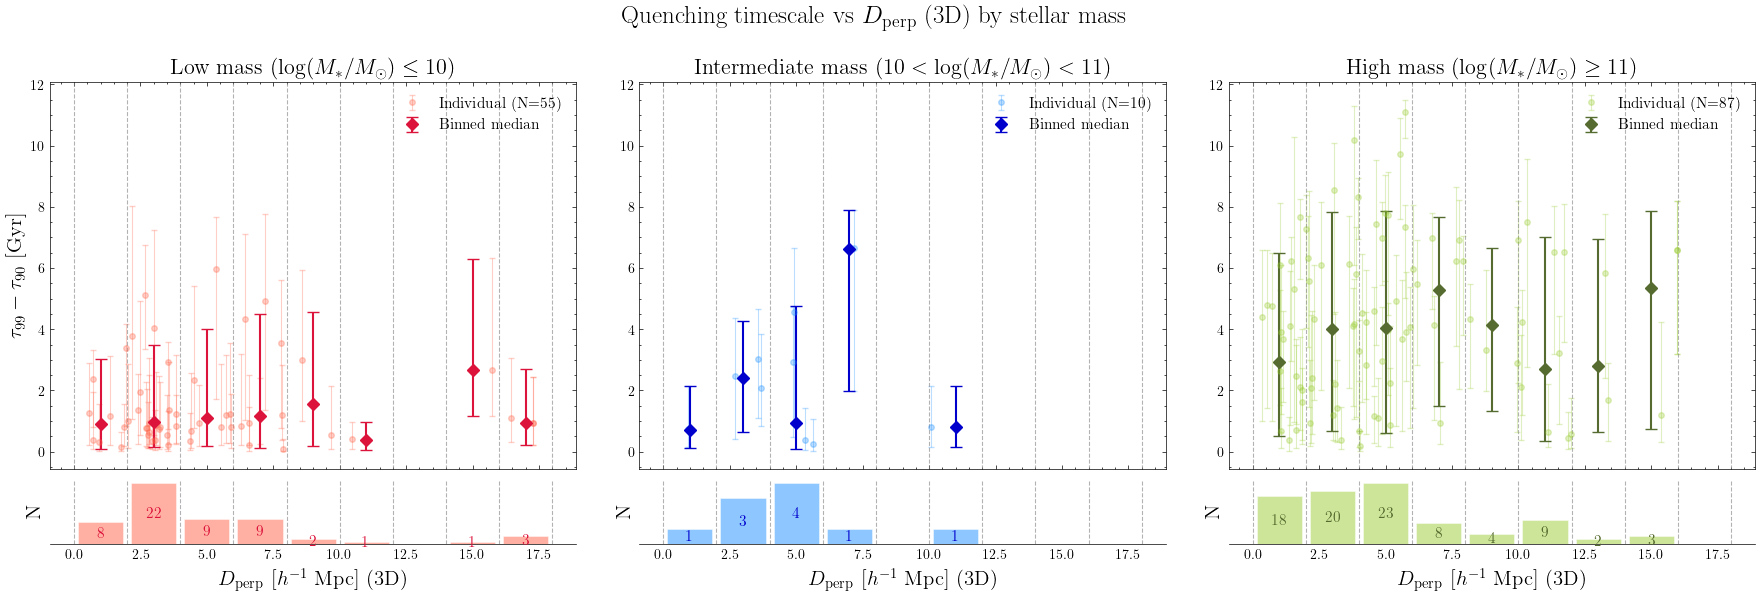

In [10]:
#----- Low, Intermediate & High Mass ----------

plot_timesc_by_mass(
    bin_edges=dfil_bin_edges,
    coord='D_fil',
    savepath='./plots/binned/3D/timesc_by_mass_dfil.pdf',
    title=r'Quenching timescale vs $D_\mathrm{perp}$ (3D) by stellar mass'
)

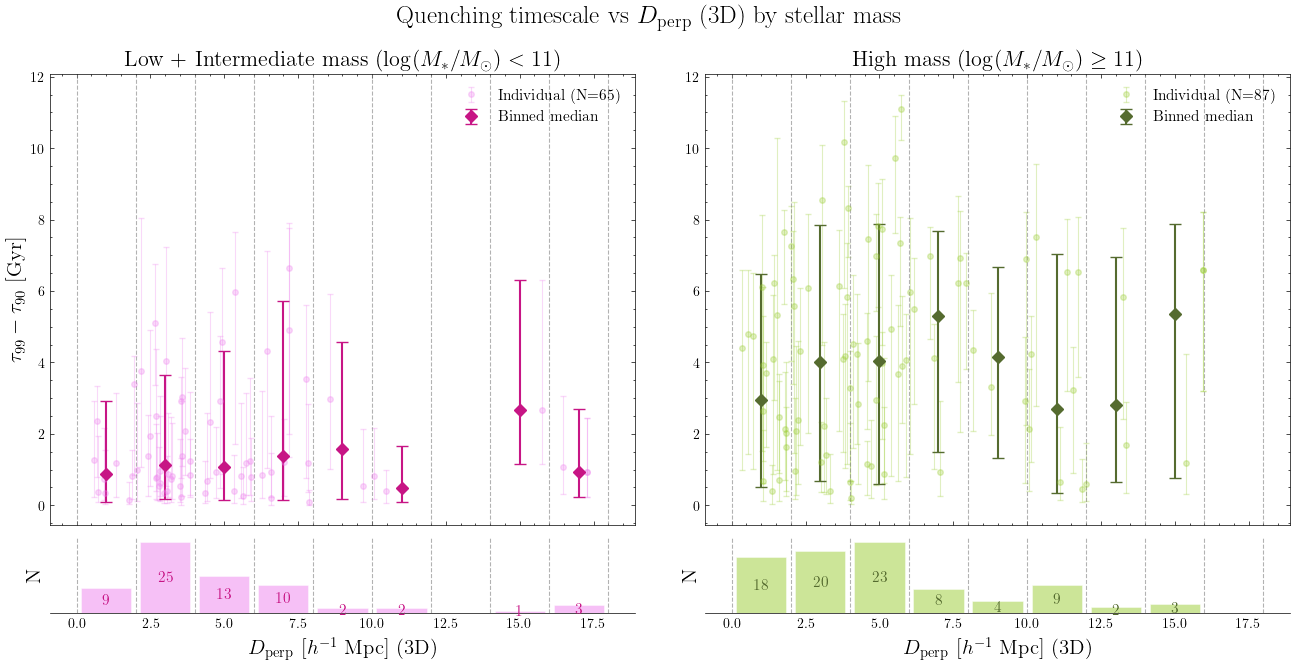

In [11]:
#----- Low & High Mass ----------

plot_timesc_by_mass_2(
    bin_edges=dfil_bin_edges,
    coord='D_fil',
    savepath='./plots/binned/3D/timesc_by_mass2_dfil.pdf',
    title=r'Quenching timescale vs $D_\mathrm{perp}$ (3D) by stellar mass'
)

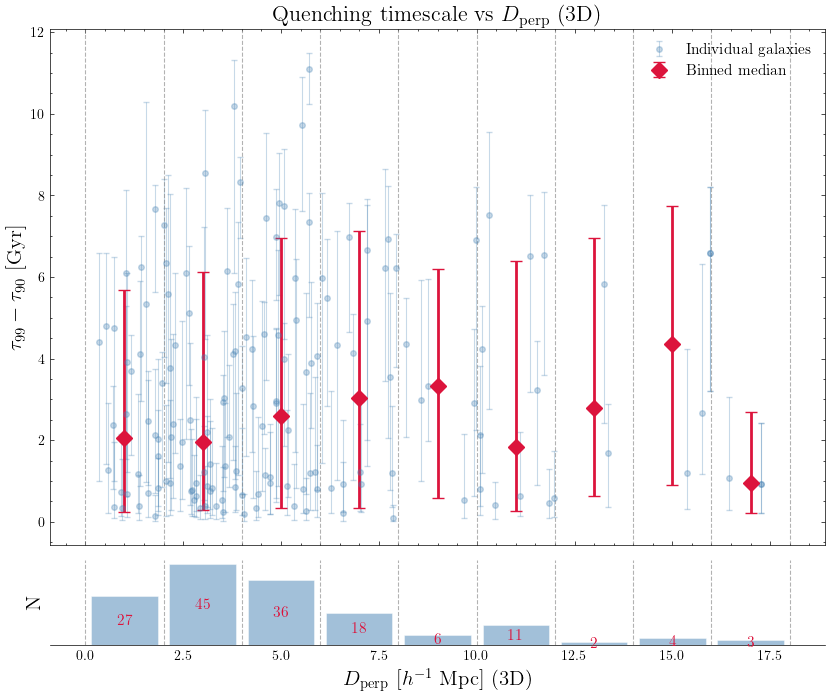

In [12]:
#----- Median Plot ----------

title = r'Quenching timescale vs $D_\mathrm{perp}$ (3D)'
savepath = './plots/binned/3D/timesc_vs_Dfil_binned.pdf'
plot_timesc(dfil_bin_df, dfil_bin_edges, coord='D_fil', savepath=savepath, title=title)

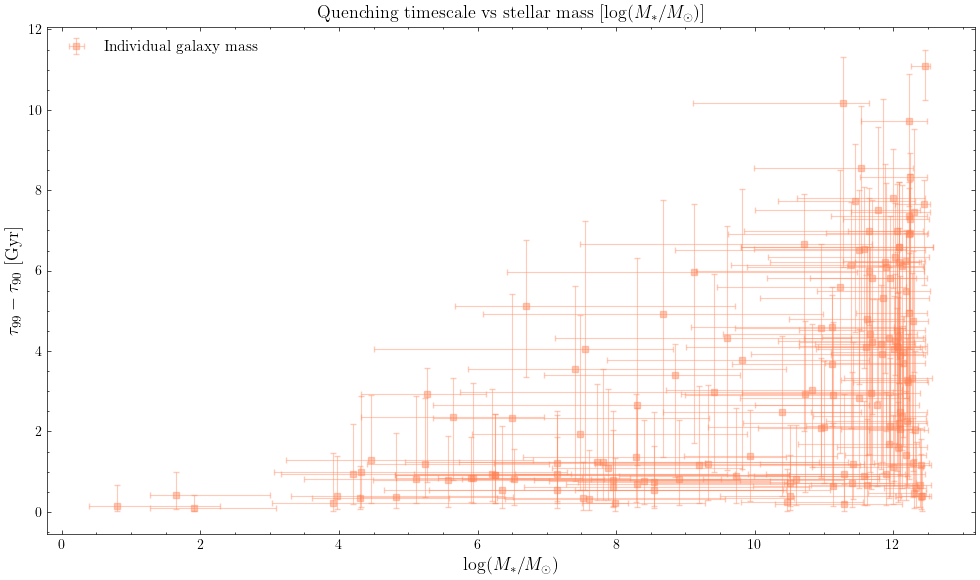

In [13]:
#----- Timescale vs Mass ----------

fig, ax = plt.subplots(figsize=(10, 6)) 

xerr = [df['err_lo_m'], df['err_hi_m']]
yerr = [df['err_lo'], df['err_hi']]

ax.errorbar(df['m_star'], df['timesc'] , yerr=yerr, xerr=xerr, fmt='s', color='coral', alpha=0.4, markersize=4, elinewidth=0.8, capsize=2, label='Individual galaxy mass', zorder=1)
ax.set_ylabel(r'$\tau_{99}-\tau_{90}$ [Gyr]', fontsize=13)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=13)
ax.set_title(r'Quenching timescale vs stellar mass [$\log(M_*/M_\odot)$]', fontsize=13)
ax.legend(fontsize=11)

savepath = './plots/mass_timesc.pdf'
plt.tight_layout()
plt.savefig(savepath)
plt.show()
plt.close(fig)

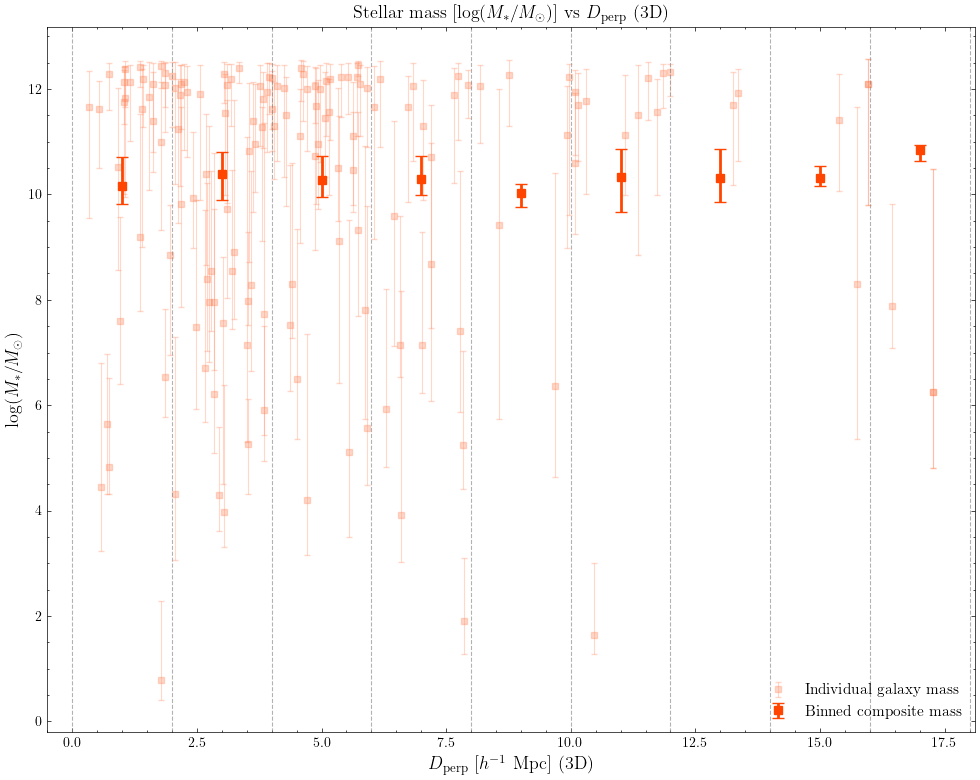

In [14]:
fig, ax = plt.subplots(figsize=(10, 8)) 

m_star = df['m_star']
dist = df['D_fil']
yerr = [df['err_lo_m'], df['err_hi_m']]
bin_yerr = [dfil_bin_df['err_lo_m'], dfil_bin_df['err_hi_m']]
dist_mids = dfil_bin_df['D_fil_mid']
m_star_mids = dfil_bin_df['mass']

ax.errorbar(dist, m_star, yerr=yerr, fmt='s', color='coral', alpha=0.3, markersize=4, elinewidth=0.8, capsize=2, label='Individual galaxy mass', zorder=1)
ax.errorbar(dist_mids, m_star_mids, yerr=bin_yerr, fmt='s', color='orangered', markersize=6, elinewidth=2, capsize=4, label='Binned composite mass', zorder=2)
for edge in dfil_bin_edges:
    ax.axvline(edge, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylabel(r'$\log(M_*/M_\odot)$', fontsize=13)
ax.set_xlabel(r'$D_\mathrm{perp}$ [$h^{-1}$ Mpc] (3D)', fontsize=13)
ax.set_title(r'Stellar mass [$\log(M_*/M_\odot)$] vs $D_\mathrm{perp}$ (3D)', fontsize=13)
ax.legend(fontsize=11)

savepath = './plots/binned/3D/mass_dfil.pdf'
plt.tight_layout()
plt.savefig(savepath)
plt.show()
plt.close(fig)

FileNotFoundError: [Errno 2] No such file or directory: '.plots/binned/3D/mean_timesc_vs_Dfil_binned.pdf'

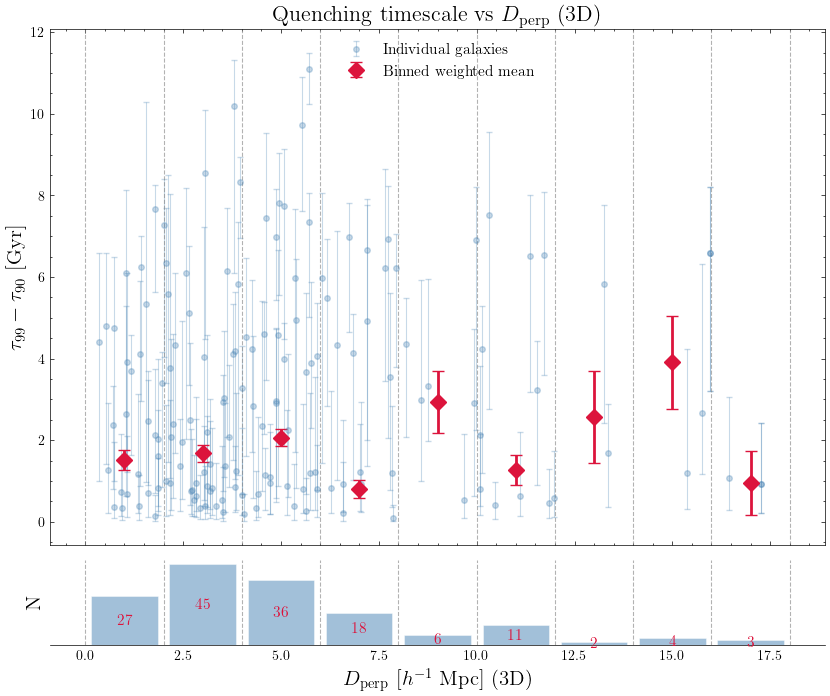

In [15]:
#----- Mean Plot ----------

title = r'Quenching timescale vs $D_\mathrm{perp}$ (3D)'
savepath = '.plots/binned/3D/mean_timesc_vs_Dfil_binned.pdf'
plot_timesc(dfil_bin_df, dfil_bin_edges, coord='D_fil', mean=True, savepath=savepath, title=title)

# 3D - Star-Forming vs Quiescent

In [ ]:
from astropy.cosmology import FlatLambdaCDM

z_filament = 0.0888  # redshift of A2142
cosmo = FlatLambdaCDM(H0=70, Om0=0.27)
t_obs = cosmo.age(z_filament).value  # in Gyr
print(f"t_obs = {t_obs:.3f} Gyr")

t99 = df['t99']

mask_recent = (t_obs - t99) < 1.0
mask_old    = (t_obs - t99) >= 1.0

In [ ]:
#----- Dfil ----------

dfil_bin_recent_df = sum_bin_post(dfil_bin_edges, coord='D_fil', df=df[mask_recent])
dfil_bin_old_df    = sum_bin_post(dfil_bin_edges, coord='D_fil', df=df[mask_old])

suptitle = r'Quenching timescale vs $D_\mathrm{perp}$ (3D)'
savepath = './plots/binned/3D/D_fil_old_recent.pdf'
plot_old_recent(dfil_bin_old_df, dfil_bin_recent_df, dfil_bin_edges, coord='D_fil', save_path=savepath, suptitle=suptitle)

# 2D

In [ ]:
dfil_2d_bin_width = 0.5
dfil_2d_bin_max = 4.5

dfil_2d_bin_edges = np.arange(0, dfil_2d_bin_max + dfil_2d_bin_width, dfil_2d_bin_width)
dfil_2d_bin_df = sum_bin_post(dfil_2d_bin_edges, coord='D_fil_2D')

In [ ]:
plot_timesc_by_mass(
    bin_edges=dfil_2d_bin_edges,
    coord='D_fil_2D',
    savepath='./plots/binned/2D_timesc_by_mass_dfil.pdf',
    title=r'Quenching timescale vs $D_\mathrm{perp}$ by stellar mass'
)

In [ ]:
plot_timesc_by_mass_2(
    bin_edges=dfil_2d_bin_edges,
    coord='D_fil_2D',
    savepath='./plots/binned/2D_timesc_by_mass2_dfil.pdf',
    title=r'Quenching timescale vs $D_\mathrm{perp}$ by stellar mass'
)

In [ ]:
#----- Median Plot ----------

title = r'Quenching timescale vs $D_\mathrm{perp}$'
savepath = './plots/binned/2D/2D_timesc_vs_Dfil_binned.pdf'
plot_timesc(dfil_2d_bin_df, dfil_2d_bin_edges, coord='D_fil_2D', savepath=savepath, title=title)

In [ ]:
#----- Timesc & t99 ----------

#title = r'Quenching timescale and t99 vs $D_\mathrm{perp}$ (2D)'
#savepath = f'./output/{nspec_folder}/plots/binned/2D/2D_timesc_t99_vs_Dfil_binned.pdf'
#plot_timesc_t99(dfil_2d_bin_df, dfil_2d_bin_edges, coord='D_fil_2D', savepath=savepath, title=title, t99_ylim=(2, 13))

In [ ]:
#----- Mean Plot ----------

title = r'Quenching timescale vs $D_\mathrm{perp}$'
savepath = './plots/binned/2D/2D_mean_timesc_vs_Dfil_binned.pdf'
plot_timesc(dfil_2d_bin_df, dfil_2d_bin_edges, coord='D_fil_2D', mean=True, savepath=savepath, title=title)

# 2D - Star-Forming vs Quiescent

In [ ]:
dfil_2d_bin_recent_df = sum_bin_post(dfil_2d_bin_edges, coord='D_fil_2D', df=df[mask_recent])
dfil_2d_bin_old_df    = sum_bin_post(dfil_2d_bin_edges, coord='D_fil_2D', df=df[mask_old])

In [ ]:
#----- 2D Dfil ----------

suptitle = r'Quenching timescale vs $D_\mathrm{perp}$'
savepath = './plots/binned/2D/2D_Dfil_old_recent.pdf'
plot_old_recent(dfil_2d_bin_old_df, dfil_2d_bin_recent_df, dfil_2d_bin_edges, coord='D_fil_2D', save_path=savepath, suptitle=suptitle)